###### *132_5_practical_lcm_weekly_site_pivot_answer.ipynb*

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
plt.rcParams["font.family"] = "Meiryo"
plt.rcParams["axes.unicode_minus"] = False

In [4]:
df = pd.read_csv(
    "dataset/lcm_weekly_defect_practice.csv",
    encoding="utf-8-sig",
)
df

,defect_id,site,model,defect_category,defect_qty,inspection_qty,occ_at_jst,status
0,D001,SUS,J69P,Buck-IC,3,30000.0,2026-06-29 08:30:00+09:00,回答済
1,D002,WSE,310D,Coil,1,28000.0,2026-06-30 13:20:00+09:00,回答済
2,D003,GSE,36WA,NTF,1,24000.0,2026-07-01 09:10:00+09:00,調査中
3,D004,META,J69P,Buck-IC,2,52000.0,2026-07-03 21:45:00+09:00,回答済
4,D005,MEAX,310D,Coil,4,18000.0,2026-07-05 11:05:00+09:00,回答済
5,D006,MELAC,3BVT,NTF,1,16000.0,2026-07-06 07:40:00+09:00,回答済
6,D007,SUS,36WA,Buck-IC,5,31000.0,2026-07-07 17:20:00+09:00,調査中
7,D008,WSE,J69P,Coil,2,30000.0,2026-07-08 19:30:00+09:00,回答済
8,D009,GSE,310D,Coil,3,22000.0,2026-07-10 10:15:00+09:00,回答済
9,D010,META,36WA,Buck-IC,2,50000.0,2026-07-12 23:55:00+09:00,回答済


In [5]:
df.dtypes

defect_id           object
site                object
model               object
defect_category     object
defect_qty          object
inspection_qty     float64
occ_at_jst          object
status              object
dtype: object

In [8]:
df["defect_qty_num"] = pd.to_numeric(
    df["defect_qty"],
    errors="coerce",
)
df["defect_qty_num"].dtypes

df["inspection_qty_num"] = pd.to_numeric(
    df["inspection_qty"],
    errors="coerce",
)
df["inspection_qty_num"].dtypes

dtype('float64')

In [9]:
df["occ_at_jst_raw"] = df["occ_at_jst"]

In [13]:
df[
    [
        "occ_at_jst",
        "occ_at_jst_raw",
    ]
].dtypes

occ_at_jst        object
occ_at_jst_raw    object
dtype: object

In [15]:
df["occ_at_jst_clean"] = (
    df["occ_at_jst"]
    .astype("string")
    .str.strip()
)

df["occ_at_jst_dt"] = pd.to_datetime(
    df["occ_at_jst_clean"],
    errors="coerce",
)

df.head(1)

,defect_id,site,model,defect_category,defect_qty,inspection_qty,occ_at_jst,status,defect_qty_num,inspection_qty_num,occ_at_jst_raw,occ_at_jst_clean,occ_at_jst_dt
0,D001,SUS,J69P,Buck-IC,3,30000.0,2026-06-29 08:30:00+09:00,回答済,3.0,30000.0,2026-06-29 08:30:00+09:00,2026-06-29 08:30:00+09:00,2026-06-29 08:30:00+09:00


In [18]:
df_data_ng = df[
    df["occ_at_jst_dt"].isna()
].copy()
df_data_ng.head()

,defect_id,site,model,defect_category,defect_qty,inspection_qty,occ_at_jst,status,defect_qty_num,inspection_qty_num,occ_at_jst_raw,occ_at_jst_clean,occ_at_jst_dt
30,D031,SUS,J69P,NTF,1,35000.0,NaN,未回答,1.0,35000.0,NaN,<NA>,NaT
33,D034,META,3BVT,NTF,1,50000.0,日付不正,未回答,1.0,50000.0,日付不正,日付不正,NaT


In [19]:
df_qty_ng = df[
    df["defect_qty_num"].isna()
].copy()
df_qty_ng.head()

,defect_id,site,model,defect_category,defect_qty,inspection_qty,occ_at_jst,status,defect_qty_num,inspection_qty_num,occ_at_jst_raw,occ_at_jst_clean,occ_at_jst_dt
31,D032,WSE,310D,Coil,不明,31000.0,2026-08-11 08:00:00+09:00,調査中,NaN,31000.0,2026-08-11 08:00:00+09:00,2026-08-11 08:00:00+09:00,2026-08-11 08:00:00+09:00


In [20]:
df_inspection_ng = df[
    df["inspection_qty_num"].isna()
].copy()
df_inspection_ng.head()

,defect_id,site,model,defect_category,defect_qty,inspection_qty,occ_at_jst,status,defect_qty_num,inspection_qty_num,occ_at_jst_raw,occ_at_jst_clean,occ_at_jst_dt
32,D033,GSE,36WA,Buck-IC,2,NaN,2026-08-12 12:30:00+09:00,回答済,2.0,NaN,2026-08-12 12:30:00+09:00,2026-08-12 12:30:00+09:00,2026-08-12 12:30:00+09:00


In [24]:
display("----- df_data_ng -----")
display(df_data_ng)
display("----- df_qty_ng -----")
display(df_qty_ng)
display("----- df_inspection_ng -----")
display(df_inspection_ng)

'----- df_data_ng -----'

,defect_id,site,model,defect_category,defect_qty,inspection_qty,occ_at_jst,status,defect_qty_num,inspection_qty_num,occ_at_jst_raw,occ_at_jst_clean,occ_at_jst_dt
30,D031,SUS,J69P,NTF,1,35000.0,NaN,未回答,1.0,35000.0,NaN,<NA>,NaT
33,D034,META,3BVT,NTF,1,50000.0,日付不正,未回答,1.0,50000.0,日付不正,日付不正,NaT


'----- df_qty_ng -----'

,defect_id,site,model,defect_category,defect_qty,inspection_qty,occ_at_jst,status,defect_qty_num,inspection_qty_num,occ_at_jst_raw,occ_at_jst_clean,occ_at_jst_dt
31,D032,WSE,310D,Coil,不明,31000.0,2026-08-11 08:00:00+09:00,調査中,NaN,31000.0,2026-08-11 08:00:00+09:00,2026-08-11 08:00:00+09:00,2026-08-11 08:00:00+09:00


'----- df_inspection_ng -----'

,defect_id,site,model,defect_category,defect_qty,inspection_qty,occ_at_jst,status,defect_qty_num,inspection_qty_num,occ_at_jst_raw,occ_at_jst_clean,occ_at_jst_dt
32,D033,GSE,36WA,Buck-IC,2,NaN,2026-08-12 12:30:00+09:00,回答済,2.0,NaN,2026-08-12 12:30:00+09:00,2026-08-12 12:30:00+09:00,2026-08-12 12:30:00+09:00


In [27]:
df_work = df[
    df["occ_at_jst_dt"].notna()
    & df["defect_qty_num"].notna()
    & df["inspection_qty_num"].notna()
].copy()
df_work

,defect_id,site,model,defect_category,defect_qty,inspection_qty,occ_at_jst,status,defect_qty_num,inspection_qty_num,occ_at_jst_raw,occ_at_jst_clean,occ_at_jst_dt
0,D001,SUS,J69P,Buck-IC,3,30000.0,2026-06-29 08:30:00+09:00,回答済,3.0,30000.0,2026-06-29 08:30:00+09:00,2026-06-29 08:30:00+09:00,2026-06-29 08:30:00+09:00
1,D002,WSE,310D,Coil,1,28000.0,2026-06-30 13:20:00+09:00,回答済,1.0,28000.0,2026-06-30 13:20:00+09:00,2026-06-30 13:20:00+09:00,2026-06-30 13:20:00+09:00
2,D003,GSE,36WA,NTF,1,24000.0,2026-07-01 09:10:00+09:00,調査中,1.0,24000.0,2026-07-01 09:10:00+09:00,2026-07-01 09:10:00+09:00,2026-07-01 09:10:00+09:00
3,D004,META,J69P,Buck-IC,2,52000.0,2026-07-03 21:45:00+09:00,回答済,2.0,52000.0,2026-07-03 21:45:00+09:00,2026-07-03 21:45:00+09:00,2026-07-03 21:45:00+09:00
4,D005,MEAX,310D,Coil,4,18000.0,2026-07-05 11:05:00+09:00,回答済,4.0,18000.0,2026-07-05 11:05:00+09:00,2026-07-05 11:05:00+09:00,2026-07-05 11:05:00+09:00
5,D006,MELAC,3BVT,NTF,1,16000.0,2026-07-06 07:40:00+09:00,回答済,1.0,16000.0,2026-07-06 07:40:00+09:00,2026-07-06 07:40:00+09:00,2026-07-06 07:40:00+09:00
6,D007,SUS,36WA,Buck-IC,5,31000.0,2026-07-07 17:20:00+09:00,調査中,5.0,31000.0,2026-07-07 17:20:00+09:00,2026-07-07 17:20:00+09:00,2026-07-07 17:20:00+09:00
7,D008,WSE,J69P,Coil,2,30000.0,2026-07-08 19:30:00+09:00,回答済,2.0,30000.0,2026-07-08 19:30:00+09:00,2026-07-08 19:30:00+09:00,2026-07-08 19:30:00+09:00
8,D009,GSE,310D,Coil,3,22000.0,2026-07-10 10:15:00+09:00,回答済,3.0,22000.0,2026-07-10 10:15:00+09:00,2026-07-10 10:15:00+09:00,2026-07-10 10:15:00+09:00
9,D010,META,36WA,Buck-IC,2,50000.0,2026-07-12 23:55:00+09:00,回答済,2.0,50000.0,2026-07-12 23:55:00+09:00,2026-07-12 23:55:00+09:00,2026-07-12 23:55:00+09:00


In [36]:
iso_df = df_work["occ_at_jst_dt"].dt.isocalendar()
iso_df

df_work["week_group"] = (
    iso_df["year"] * 100
    + iso_df["week"]
).astype(int)
df_work

,defect_id,site,model,defect_category,defect_qty,inspection_qty,occ_at_jst,status,defect_qty_num,inspection_qty_num,occ_at_jst_raw,occ_at_jst_clean,occ_at_jst_dt,week_group
0,D001,SUS,J69P,Buck-IC,3,30000.0,2026-06-29 08:30:00+09:00,回答済,3.0,30000.0,2026-06-29 08:30:00+09:00,2026-06-29 08:30:00+09:00,2026-06-29 08:30:00+09:00,202627
1,D002,WSE,310D,Coil,1,28000.0,2026-06-30 13:20:00+09:00,回答済,1.0,28000.0,2026-06-30 13:20:00+09:00,2026-06-30 13:20:00+09:00,2026-06-30 13:20:00+09:00,202627
2,D003,GSE,36WA,NTF,1,24000.0,2026-07-01 09:10:00+09:00,調査中,1.0,24000.0,2026-07-01 09:10:00+09:00,2026-07-01 09:10:00+09:00,2026-07-01 09:10:00+09:00,202627
3,D004,META,J69P,Buck-IC,2,52000.0,2026-07-03 21:45:00+09:00,回答済,2.0,52000.0,2026-07-03 21:45:00+09:00,2026-07-03 21:45:00+09:00,2026-07-03 21:45:00+09:00,202627
4,D005,MEAX,310D,Coil,4,18000.0,2026-07-05 11:05:00+09:00,回答済,4.0,18000.0,2026-07-05 11:05:00+09:00,2026-07-05 11:05:00+09:00,2026-07-05 11:05:00+09:00,202627
5,D006,MELAC,3BVT,NTF,1,16000.0,2026-07-06 07:40:00+09:00,回答済,1.0,16000.0,2026-07-06 07:40:00+09:00,2026-07-06 07:40:00+09:00,2026-07-06 07:40:00+09:00,202628
6,D007,SUS,36WA,Buck-IC,5,31000.0,2026-07-07 17:20:00+09:00,調査中,5.0,31000.0,2026-07-07 17:20:00+09:00,2026-07-07 17:20:00+09:00,2026-07-07 17:20:00+09:00,202628
7,D008,WSE,J69P,Coil,2,30000.0,2026-07-08 19:30:00+09:00,回答済,2.0,30000.0,2026-07-08 19:30:00+09:00,2026-07-08 19:30:00+09:00,2026-07-08 19:30:00+09:00,202628
8,D009,GSE,310D,Coil,3,22000.0,2026-07-10 10:15:00+09:00,回答済,3.0,22000.0,2026-07-10 10:15:00+09:00,2026-07-10 10:15:00+09:00,2026-07-10 10:15:00+09:00,202628
9,D010,META,36WA,Buck-IC,2,50000.0,2026-07-12 23:55:00+09:00,回答済,2.0,50000.0,2026-07-12 23:55:00+09:00,2026-07-12 23:55:00+09:00,2026-07-12 23:55:00+09:00,202628


In [38]:
df_week_site_summary = df_work.groupby(
    [
        "week_group",
        "site",
    ],
    as_index=False,
).agg(
    defect_count=("defect_id", "count"),
    defect_qty_sum=("defect_qty_num", "sum"),
    inspection_qty_sum=("inspection_qty_num", "sum"),
)
df_week_site_summary.head()

,week_group,site,defect_count,defect_qty_sum,inspection_qty_sum
0,202627,GSE,1,1.0,24000.0
1,202627,MEAX,1,4.0,18000.0
2,202627,META,1,2.0,52000.0
3,202627,SUS,1,3.0,30000.0
4,202627,WSE,1,1.0,28000.0


In [40]:
df_week_site_summary["ppm"] = (
    df_week_site_summary["defect_qty_sum"]
    / df_week_site_summary["inspection_qty_sum"]
    * 1000000
).round(1)
df_week_site_summary["ppm"].head()

0     41.7
1    222.2
2     38.5
3    100.0
4     35.7
Name: ppm, dtype: float64

In [41]:
df_week_site_summary["defect_qty_sum"] =(
    df_week_site_summary["defect_qty_sum"].astype(int)
)

In [43]:
df_week_site_summary["inspection_qty_sum"] = (
    df_week_site_summary["inspection_qty_sum"].astype(int)
)
df_week_site_summary.head(1)

,week_group,site,defect_count,defect_qty_sum,inspection_qty_sum,ppm
0,202627,GSE,1,1,24000,41.7


In [48]:
df_week_site_pivot = df_week_site_summary.pivot_table(
    index="week_group",
    columns="site",
    values="defect_qty_sum",
    fill_value=0,
).reset_index()

df_week_site_pivot.columns.name = None

df_week_site_pivot

,week_group,GSE,MEAX,MELAC,META,SUS,WSE
0,202627,1.0,4.0,0.0,2.0,3.0,1.0
1,202628,3.0,0.0,1.0,2.0,5.0,2.0
2,202629,1.0,1.0,3.0,0.0,4.0,1.0
3,202630,0.0,2.0,2.0,3.0,1.0,4.0
4,202631,2.0,1.0,3.0,1.0,0.0,0.0
5,202632,1.0,3.0,0.0,2.0,2.0,1.0
6,202633,0.0,0.0,1.0,0.0,0.0,0.0


In [50]:
site_cols = [
    "SUS",
    "WSE",
    "GSE",
    "META",
    "MEAX",
    "MELAC",
]

df_week_site_pivot = df_week_site_pivot[
    [
        "week_group",
    ]
    + site_cols
]

df_week_site_pivot[site_cols] = (
    df_week_site_pivot[site_cols].astype(int)
)
df_week_site_pivot

,week_group,SUS,WSE,GSE,META,MEAX,MELAC
0,202627,3,1,1,2,4,0
1,202628,5,2,3,2,0,1
2,202629,4,1,1,0,1,3
3,202630,1,4,0,3,2,2
4,202631,0,0,2,1,1,3
5,202632,2,1,1,2,3,0
6,202633,0,0,0,0,0,1


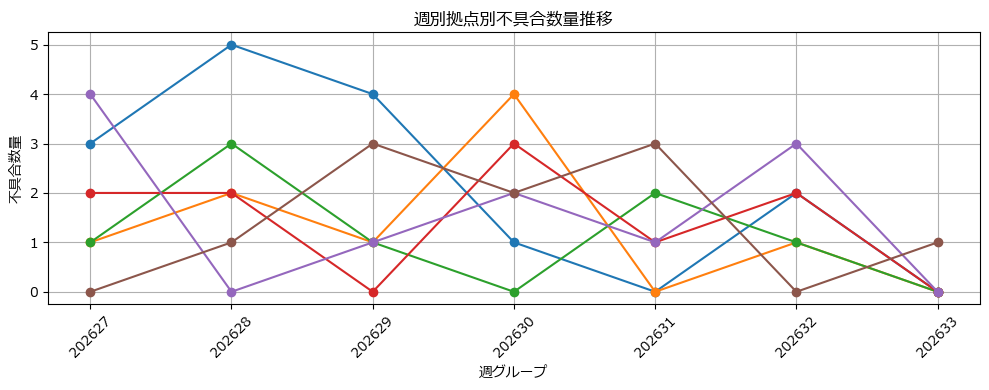

In [60]:
plt.figure(figsize=(10, 4))

for site in site_cols:
    plt.plot(
        df_week_site_pivot["week_group"].astype(str),
        df_week_site_pivot[site],
        marker="o",
        label=site,
    )
plt.title("週別拠点別不具合数量推移")
plt.xlabel("週グループ")
plt.ylabel("不具合数量")
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()